# 05 Credit Risk

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/blob/main/09-Finance/05_Credit_Risk.ipynb) [![Launch Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/main?filepath=09-Finance/05_Credit_Risk.ipynb) [![Code License: MIT](https://img.shields.io/badge/Code%20License-MIT-yellow.svg)](../LICENSE) [![Content License: CC BY 4.0](https://img.shields.io/badge/Content%20License-CC%20BY%204.0-blue.svg)](https://creativecommons.org/licenses/by/4.0/)


In [1]:
# === Environment Setup ===
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# --- Configuration ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 14, 'figure.figsize': (12, 8), 'figure.dpi': 150})
%config InlineBackend.figure_format = 'retina'
np.set_printoptions(suppress=True, linewidth=120, precision=4)


### Table of Contents

1.  [Introduction: The Option to Default](#1-introduction-the-option-to-default)
2.  [Structural Models: The Merton (1974) Framework](#2-structural-models-the-merton-1974-framework)
    - [Equity as a Call Option](#equity-as-a-call-option)
    - [Implementation and Sensitivity Analysis](#implementation-and-sensitivity-analysis)
3.  [Reduced-Form Models: Jarrow-Turnbull (1995)](#3-reduced-form-models-jarrow-turnbull-1995)
    - [Hazard Rates and Default Intensity](#Hazard-Rates-and-Default-Intensity)
4.  [Application: Calibrating Merton's Model to Real Data](#4-application-calibrating-mertons-model-to-real-data)

    - [Calculating Distance-to-Default (DD)](#calculating-distance-to-default-dd)
5.  [The Credit Spread Puzzle](#5-the-credit-spread-puzzle)
6.  [Summary](#summary)
7.  [Exercises](#7-exercises)


## The Lens: Default as a Rational Choice
**What economic problem are we solving?**
When you lend money to a company, you face a risk: they might not pay you back. This is **credit risk**. How do we price this risk? How much extra interest should a risky company pay compared to the US government? To answer this, we need to understand *why* firms default.

**Why do we need this method?**
Default isn't just bad luck; it's an economic decision. Robert Merton's brilliant insight was to treat a firm's equity as a **call option** on its assets. If the assets are worth more than the debt, shareholders pay the debt and keep the difference (exercise the option). If assets are worth less, they walk away (let the option expire). This structural view links stock prices, volatility, and leverage directly to the probability of default, giving us a powerful tool to price corporate bonds and credit default swaps (CDS).

### Learning Objectives
* **Model** equity as a call option on firm assets using the Merton (1974) framework.
* **Compute** the distance-to-default and implied default probabilities from market data.
* **Price** credit default swaps (CDS) and corporate bond spreads.
* **Compare** structural (Merton) and reduced-form (Jarrow-Turnbull) approaches to credit risk.

### Prerequisites
* **Option Pricing:** Black-Scholes formula and put-call parity (Module 09 - Option Pricing).
* **Continuous-Time Finance:** GBM and Ito's Lemma (Module 09 - Continuous-Time Finance).
* **Statistics:** Normal distribution, cumulative distribution functions.
* **Learning-path prerequisite:** [`04_Continuous_Time_Finance.ipynb`](04_Continuous_Time_Finance.ipynb)


> **Learning path:** Building on [`04_Continuous_Time_Finance.ipynb`](04_Continuous_Time_Finance.ipynb); next continue with [`06_High_Frequency_Data.ipynb`](06_High_Frequency_Data.ipynb).


### 1. Introduction: The Option to Default

Credit risk modeling generally falls into two camps:
1.  **Structural Models (Merton):** View default as an endogenous event triggered when firm value falls below a threshold (the debt face value). These models use option pricing theory to value corporate liabilities.
2.  **Reduced-Form Models (Jarrow-Turnbull):** Treat default as an exogenous random event governed by a hazard rate (intensity), similar to how actuaries model mortality.

This notebook focuses on the structural approach, which provides the deepest economic intuition.


### 2. Structural Models: The Merton (1974) Framework

![Merton model payoffs](../images/09-Finance/merton_model_payoffs.png)

*Figure: Equity as a call option on firm assets in the Merton model.*

The Merton model assumes a firm has a simple capital structure: equity and a single zero-coupon bond with face value $F$ maturing at time $T$. The firm's asset value $V_A$ follows a Geometric Brownian Motion.

#### Equity as a Call Option
At maturity $T$, the payoff to equity holders is:
$$ E_T = \max(V_A(T) - F, 0) $$
This is exactly the payoff of a **European Call Option** on the firm's assets with strike price $F$. Therefore, we can value the firm's equity using the Black-Scholes formula:
$$ E_0 = V_0 N(d_1) - F e^{-rT} N(d_2) $$

The debt holders get whatever is left. The value of risky debt is:
$$ D_0 = V_0 - E_0 $$
This implies risky debt is equivalent to a risk-free bond *minus* the value of a put option on the firm's assets (the "default put").

**Dimension notes:** firm asset value $V_A$ scalar GBM; debt face value $F$, maturity $T$ constants; equity is the scalar call payoff $\max(V_A(T) - F, 0)$, so $E_0, \sigma_E$ link to unobservables $(V_0, \sigma_A)$ through two equations.

In [2]:
### Merton Model Implementation
def merton_credit_metrics(V, F, T, r, sigma):
    """Calculates equity, debt, and default probability using Merton's model."""
    d1 = (np.log(V / F) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    # Value of equity (Call Option)
    E = V * norm.cdf(d1) - np.exp(-r * T) * F * norm.cdf(d2)

    # Value of debt (Assets - Equity)
    D = V - E

    # Yield to maturity on the risky debt
    y = -np.log(D/F) / T

    # Credit Spread
    spread = y - r

    # Risk-Neutral Probability of Default (Probability that V_T < F)
    # P(V_T < F) = N(-d2)
    prob_default = norm.cdf(-d2)

    return {'Equity': E, 'Debt': D, 'Yield': y, 'Spread': spread, 'PD': prob_default}

# Example parameters
V0, F_debt, T, r, sigma_A = 100, 80, 1, 0.05, 0.2
results = merton_credit_metrics(V0, F_debt, T, r, sigma_A)

print("> **Note:** Merton Model Results:")
for k, v in results.items():
    print(f"  {k}: {v:.4f}")


> **Note:** Merton Model Results:
  Equity: 24.5888
  Debt: 75.4112
  Yield: 0.0591
  Spread: 0.0091
  PD: 0.1028


#### Implementation and Sensitivity Analysis
Let's see how credit spreads respond to changes in leverage and asset volatility. This is crucial for understanding why spreads widen during crises (when asset values fall and volatility spikes).


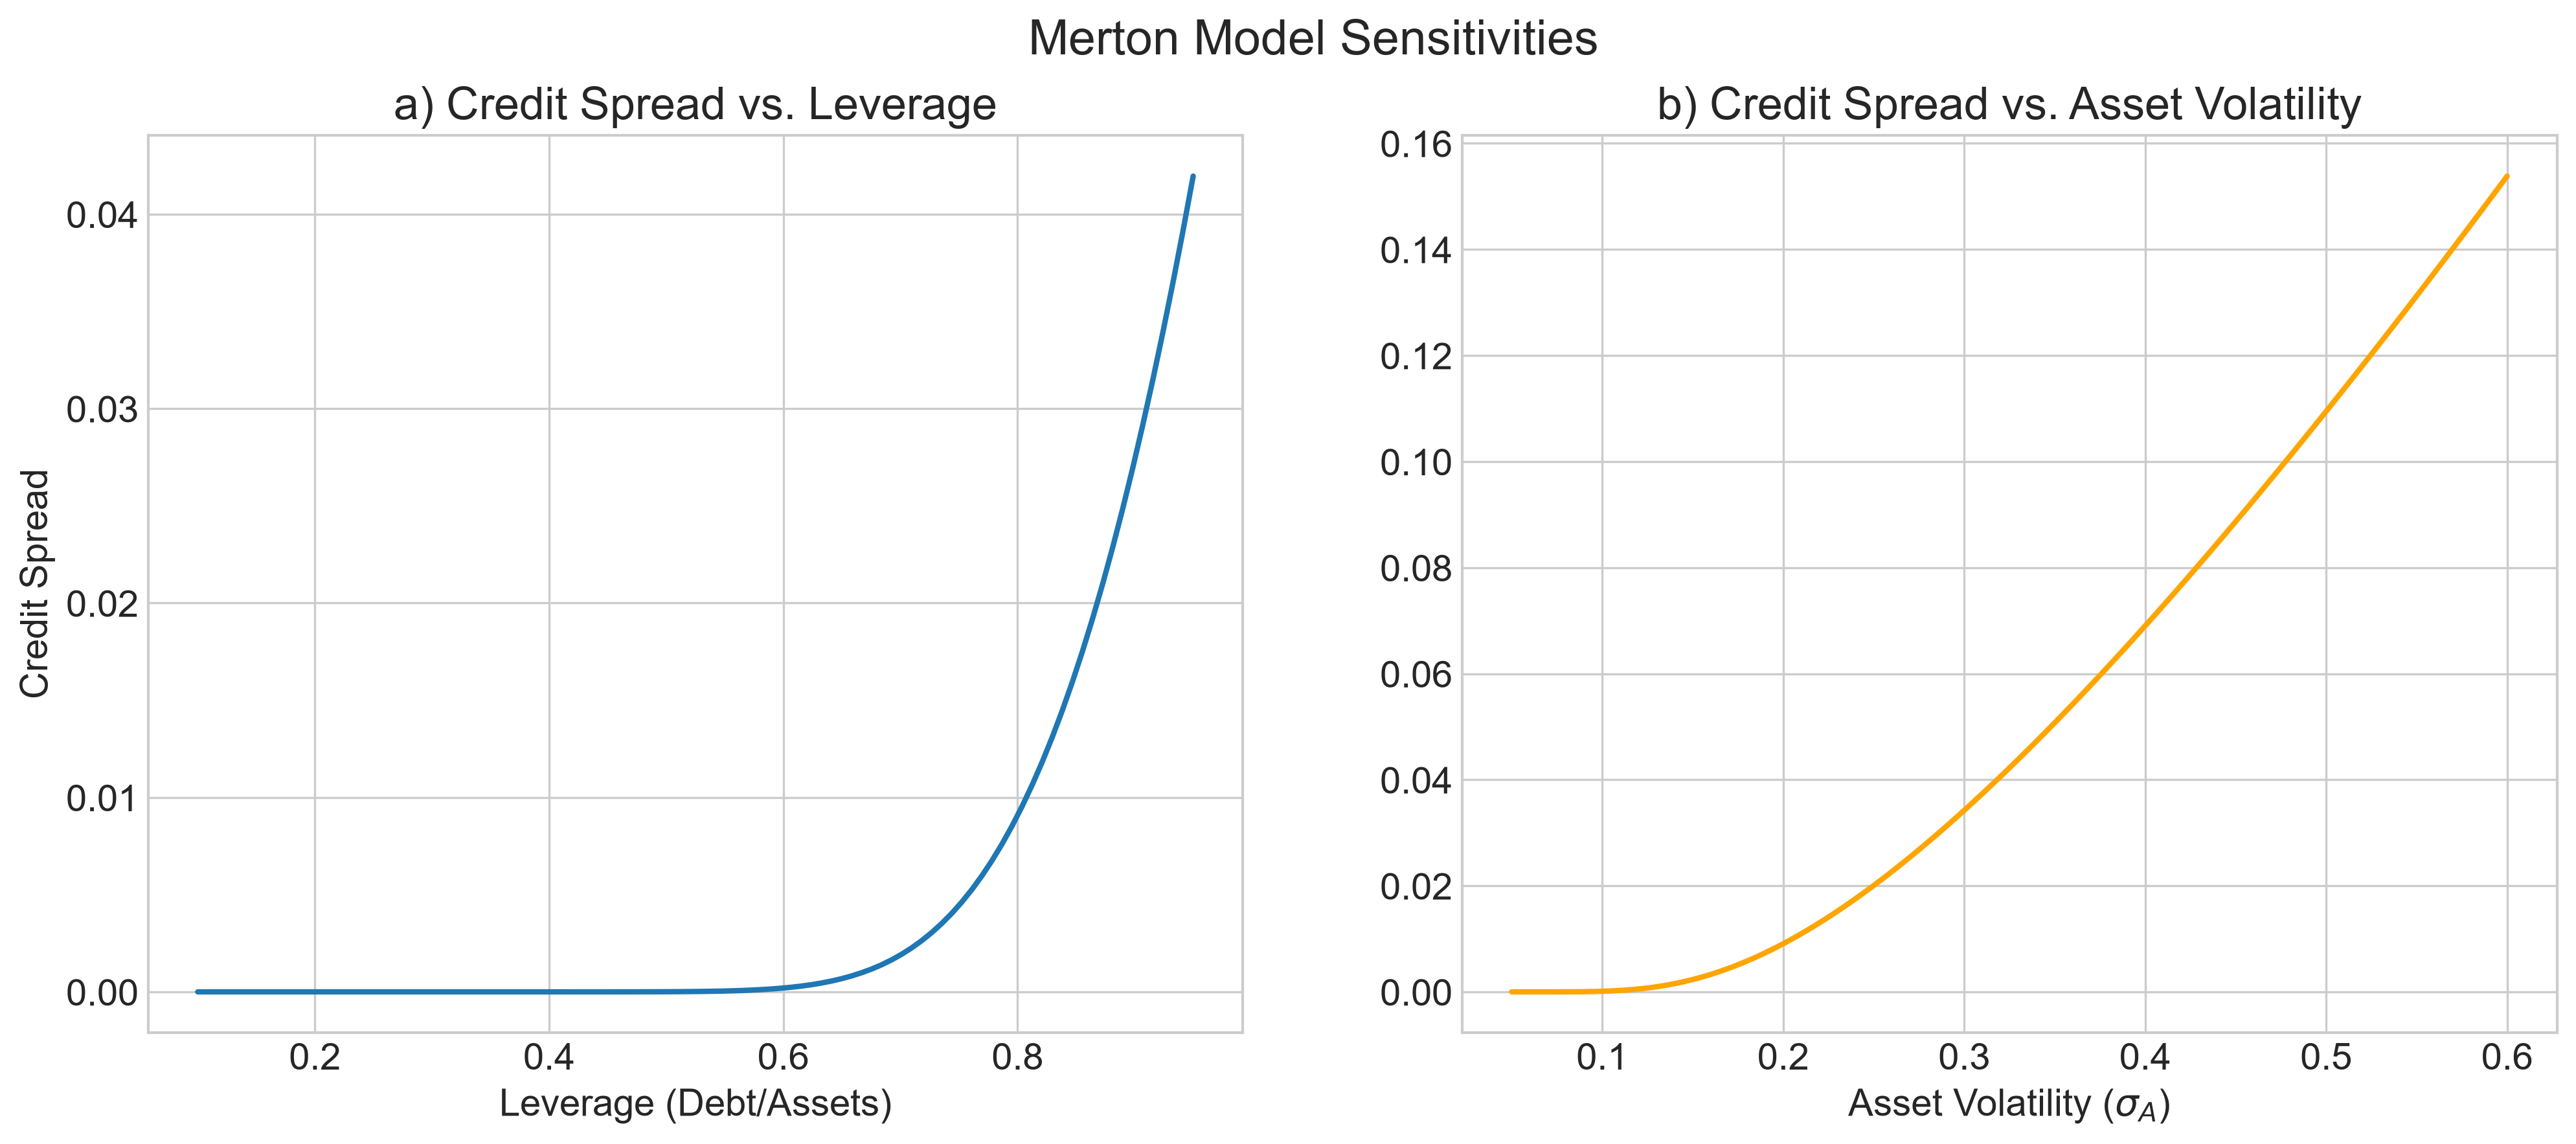

In [3]:
### Sensitivity Analysis of Credit Spreads

# 1. Sensitivity to Leverage (Debt/Assets)
leverage_ratios = np.linspace(0.1, 0.95, 100)
spreads_lev = [merton_credit_metrics(100, 100*L, 1, 0.05, 0.2)['Spread'] for L in leverage_ratios]

# 2. Sensitivity to Asset Volatility
volatilities = np.linspace(0.05, 0.6, 100)
spreads_vol = [merton_credit_metrics(100, 80, 1, 0.05, v)['Spread'] for v in volatilities]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Merton Model Sensitivities", fontsize=18)

ax1.plot(leverage_ratios, spreads_lev, lw=2)
ax1.set_title('a) Credit Spread vs. Leverage')
ax1.set_xlabel('Leverage (Debt/Assets)')
ax1.set_ylabel('Credit Spread')

ax2.plot(volatilities, spreads_vol, lw=2, color='orange')
ax2.set_title('b) Credit Spread vs. Asset Volatility')
ax2.set_xlabel(r'Asset Volatility ($\sigma_A$)')

for ax in [ax1, ax2]: ax.grid(True)
plt.show() # Render plot


### 3. Reduced-Form Models: Jarrow-Turnbull (1995)

Reduced-form models ignore the firm's assets. Instead, they assume default arrives with a certain intensity $\lambda$. The probability of default over a small time $dt$ is $\lambda dt$. The value of a risky bond is:
$$ D(0, T) = F e^{-(r+\lambda(1-R))T} $$
where $R$ is the recovery rate. The credit spread is simply $s = \lambda(1-R)$. These models are easier to calibrate to market data (e.g., the term structure of spreads) but lack the structural economic intuition of Merton.

**Dimension notes:** default intensity $\lambda \ge 0$ scalar hazard; survival probability $e^{-\lambda T}$ scalar; credit spread enters the discount rate additively, keeping bond values scalar.

## Hazard Rates and Default Intensity

Reduced-form models treat default as the first arrival of a Poisson-type process with intensity $\lambda(t)$, also called the hazard rate. The survival probability to horizon $T$ is then $Q(\tau > T) = \exp\left(-\int_0^T \lambda(s)\,ds\right)$, and under recovery $R$ the credit spread on a short bond is approximately $\lambda(1-R)$. This is the modeling language of the Jarrow–Turnbull framework above.


### 4. Application: Calibrating Merton's Model to Real Data

Merton's model is elegant, but it has a problem: **we cannot observe the market value of a firm's assets ($V_A$) or their volatility ($\sigma_A$).** We only observe the value of Equity ($E$) and its volatility ($\sigma_E$).

To make the model usable, we treat $V_A$ and $\sigma_A$ as unknowns to be solved for. We have two equations:
1.  **Equity Pricing Equation:** $E = \text{Call}(V_A, \sigma_A, F, T, r)$
2.  **Itô's Lemma for Equity Volatility:** The volatility of equity is related to asset volatility by the elasticity of equity value with respect to asset value:
    $$ \sigma_E = \frac{V_A}{E} \Delta_{\text{Call}} \sigma_A = \frac{V_A}{E} N(d_1) \sigma_A $$

This gives us a system of two non-linear equations with two unknowns ($V_A, \sigma_A$). Commercial providers like **KMV (now Moody's Analytics)** use an iterative algorithm to solve this system.

**Dimension notes:** observable inputs: equity value $E$ and volatility $\sigma_E$ (scalars); unknowns $(V_0, \sigma_A)$ solved from the valuation equation plus Ito-matched volatility equation — two equations, two unknowns.

In [ ]:
### The KMV Iterative Algorithm
from scipy.optimize import fsolve


def solve_merton_kmv(E_obs, sigma_E_obs, F, T, r):
    """
    Solves for unobservable Asset Value (V) and Asset Volatility (sigma_A)
    given observable Equity Value (E) and Equity Volatility (sigma_E).
    """
    def system(x):
        V, sigma_A = x
        # Prevent negative values during solver steps
        if V <= 0 or sigma_A <= 0: return [1e6, 1e6]

        d1 = (np.log(V / F) + (r + 0.5 * sigma_A**2) * T) / (sigma_A * np.sqrt(T))
        d2 = d1 - sigma_A * np.sqrt(T)

        # Eq 1: Equity value
        eq1 = (V * norm.cdf(d1) - F * np.exp(-r * T) * norm.cdf(d2)) - E_obs

        # Eq 2: Equity volatility relationship: sigma_E * E = sigma_A * V * N(d1)
        eq2 = (sigma_A * V * norm.cdf(d1)) - (sigma_E_obs * E_obs)

        return [eq1, eq2]

    # Initial guess: V ~ E + F, sigma_A ~ sigma_E * (E/V)
    V_guess = E_obs + F
    sigma_guess = sigma_E_obs * (E_obs / V_guess)

    solution, info, ier, message = fsolve(
        system, [V_guess, sigma_guess], full_output=True
    )
    V_implied, sigma_A_implied = solution
    residual = np.max(np.abs(system(solution)))

    if ier != 1 or not np.isfinite(solution).all() or residual > 1e-8:
        raise RuntimeError(
            "KMV calibration did not converge to a verified root: "
            f"ier={ier}, residual={residual:.3e}, message={message.strip()}"
        )
    if V_implied <= 0 or sigma_A_implied <= 0:
        raise ValueError("KMV solver returned a non-positive asset value or volatility.")
    return V_implied, sigma_A_implied

# Example Calibration
E_market = 50 # Market Cap (e.g., $50B)
sigma_E_market = 0.40 # Annualized Stock Volatility (40%)
Debt_Face = 40 # Face Value of Debt ($40B)
T_debt = 1 # 1 year horizon
r_rate = 0.02

V_calib, sigma_calib = solve_merton_kmv(E_market, sigma_E_market, Debt_Face, T_debt, r_rate)

print("> **Note:** Calibration Results:")
print(f"  Implied Asset Value (V_A): ${V_calib:.2f}B")
print(f"  Implied Asset Volatility (sigma_A): {sigma_calib:.2%}")

# Calculate Distance to Default
DD = (V_calib - Debt_Face) / (V_calib * sigma_calib)
print(f"  Distance-to-Default (DD): {DD:.2f} standard deviations")


#### Calculating Distance-to-Default (DD)
The **Distance-to-Default (DD)** is the most popular metric from the KMV model. It measures how many standard deviations the asset value is away from the default barrier (debt face value). 
$$ \text{DD} = \frac{V_A - F}{V_A \sigma_A} $$
A higher DD implies a safer firm. This metric is widely used by banks and hedge funds to rank companies by creditworthiness. Note the assumption it carries: default is triggered exactly at the debt face value at a single horizon. Adding a default barrier, a longer horizon, or a drift term changes the distance and, with it, the ranking.


### 5. The Credit Spread Puzzle

While the Merton model is brilliant, it consistently underpredicts actual market credit spreads. This is the **credit spread puzzle**. Even for very safe firms with almost zero default probability in the model, market spreads are significantly positive.

**Why?**
1.  **Liquidity:** Corporate bonds are less liquid than Treasuries. Investors demand a premium for this illiquidity, which the Merton model interprets as default risk.
2.  **Jumps:** Asset prices can jump downwards (e.g., due to fraud or sudden regulation). GBM assumes continuous paths, underestimating the risk of sudden default.
3.  **Taxes:** Corporate interest payments are tax-deductible, which affects bond pricing.


## Key Equations

These relations are collected from the derivations above as a review map. Their assumptions and derivations remain part of the result; this box is not a substitute for them.

**1. Core relation**

$$E_T = \max(V_A(T) - F, 0)$$

**2. Core relation**

$$E_0 = V_0 N(d_1) - F e^{-rT} N(d_2)$$

**3. Core relation**

$$D_0 = V_0 - E_0$$

**4. Core relation**

$$D(0, T) = F e^{-(r+\lambda(1-R))T}$$

**Dimension notes:** payoffs and values are scalars; $N(d_1), N(d_2)$ standard normal cdfs at scalar arguments; distances-to-default are standardized scalar statistics.

### Three-Tier Practice Ladder

**1. Mechanism and assumptions (Conceptual):** Derive the no-arbitrage, optimality, or risk-pricing relation central to **05 Credit Risk** and verify that it satisfies at least two economically meaningful limiting cases or bounds.

**2. Reproduce and diagnose (Applied):** Reproduce a calculation from 1. Introduction: The Option to Default, 2. Structural Models: The Merton (1974) Framework with transparent inputs. Perturb volatility, discounting, risk aversion, transaction costs, or another key parameter and explain the sensitivity in economic terms.

**3. Robust extension (Challenge):** Construct a stress scenario outside the calibration sample. Compare two valuation/risk methods and explain which discrepancy reflects model risk rather than numerical error.

**3b. Failure analysis (Challenge):** Distance-to-default computed with *equity* volatility is wildly off, and the KMV iteration to back out asset volatility does not converge. Diagnose the wrong-volatility mapping, repair with the standard iterative asset-volatility solve, and verify convergence plus sanity of $(V_0, \sigma_A)$.

> Use the existing exercises above when they target the same skill; this ladder makes the intended progression explicit rather than replacing instructor-authored problems.


# Summary

**What did we learn?**
- **Default as an Option:** Merton's structural model treats equity as a call option on the firm's assets. Default occurs rationally when assets < debt.
- **Linkage:** This framework links equity markets (stock price, volatility) to credit markets (bond yields, spreads). A rise in stock volatility increases the value of equity (option) but decreases the value of debt.
- **Calibration:** Since asset values are unobservable, we use the KMV algorithm to back them out from observable equity data.
- **Distance-to-Default:** A key output of the calibrated model, providing a normalized measure of credit health.

**What is the key takeaway?**
Credit risk is not a separate silo; it is derivatives pricing in disguise. By viewing the capital structure through the lens of options, we gain a unified understanding of corporate value.


### 7. Exercises

1.  **Equity as Volatility:** In the Merton model, if a firm's asset volatility increases (all else equal), what happens to the value of its equity? What happens to the value of its debt? Explain the intuition using option theory (Vega).

2.  **KMV Algorithm:** Why do we need an iterative solver for the KMV model? Why can't we just observe the volatility of the firm's assets directly from its balance sheet?

3.  **Subordinated Debt:** Suppose a firm has two layers of debt: Senior ($F_1$) and Junior ($F_2$). How would you model the Junior debt as an option? (Hint: It pays off only if $V > F_1$. It's like a call spread).

4.  **Default Probability:** Using the calibrated values from the case study, calculate the real-world probability of default. How does this compare to the risk-neutral probability $N(-d_2)$? Which one should be higher?


Firm Asset Value: 100
Debt Face Value:  80
------------------------------
Equity Value:             24.5888
Probability of Default:   10.2807%
Credit Spread:            90.71 bps


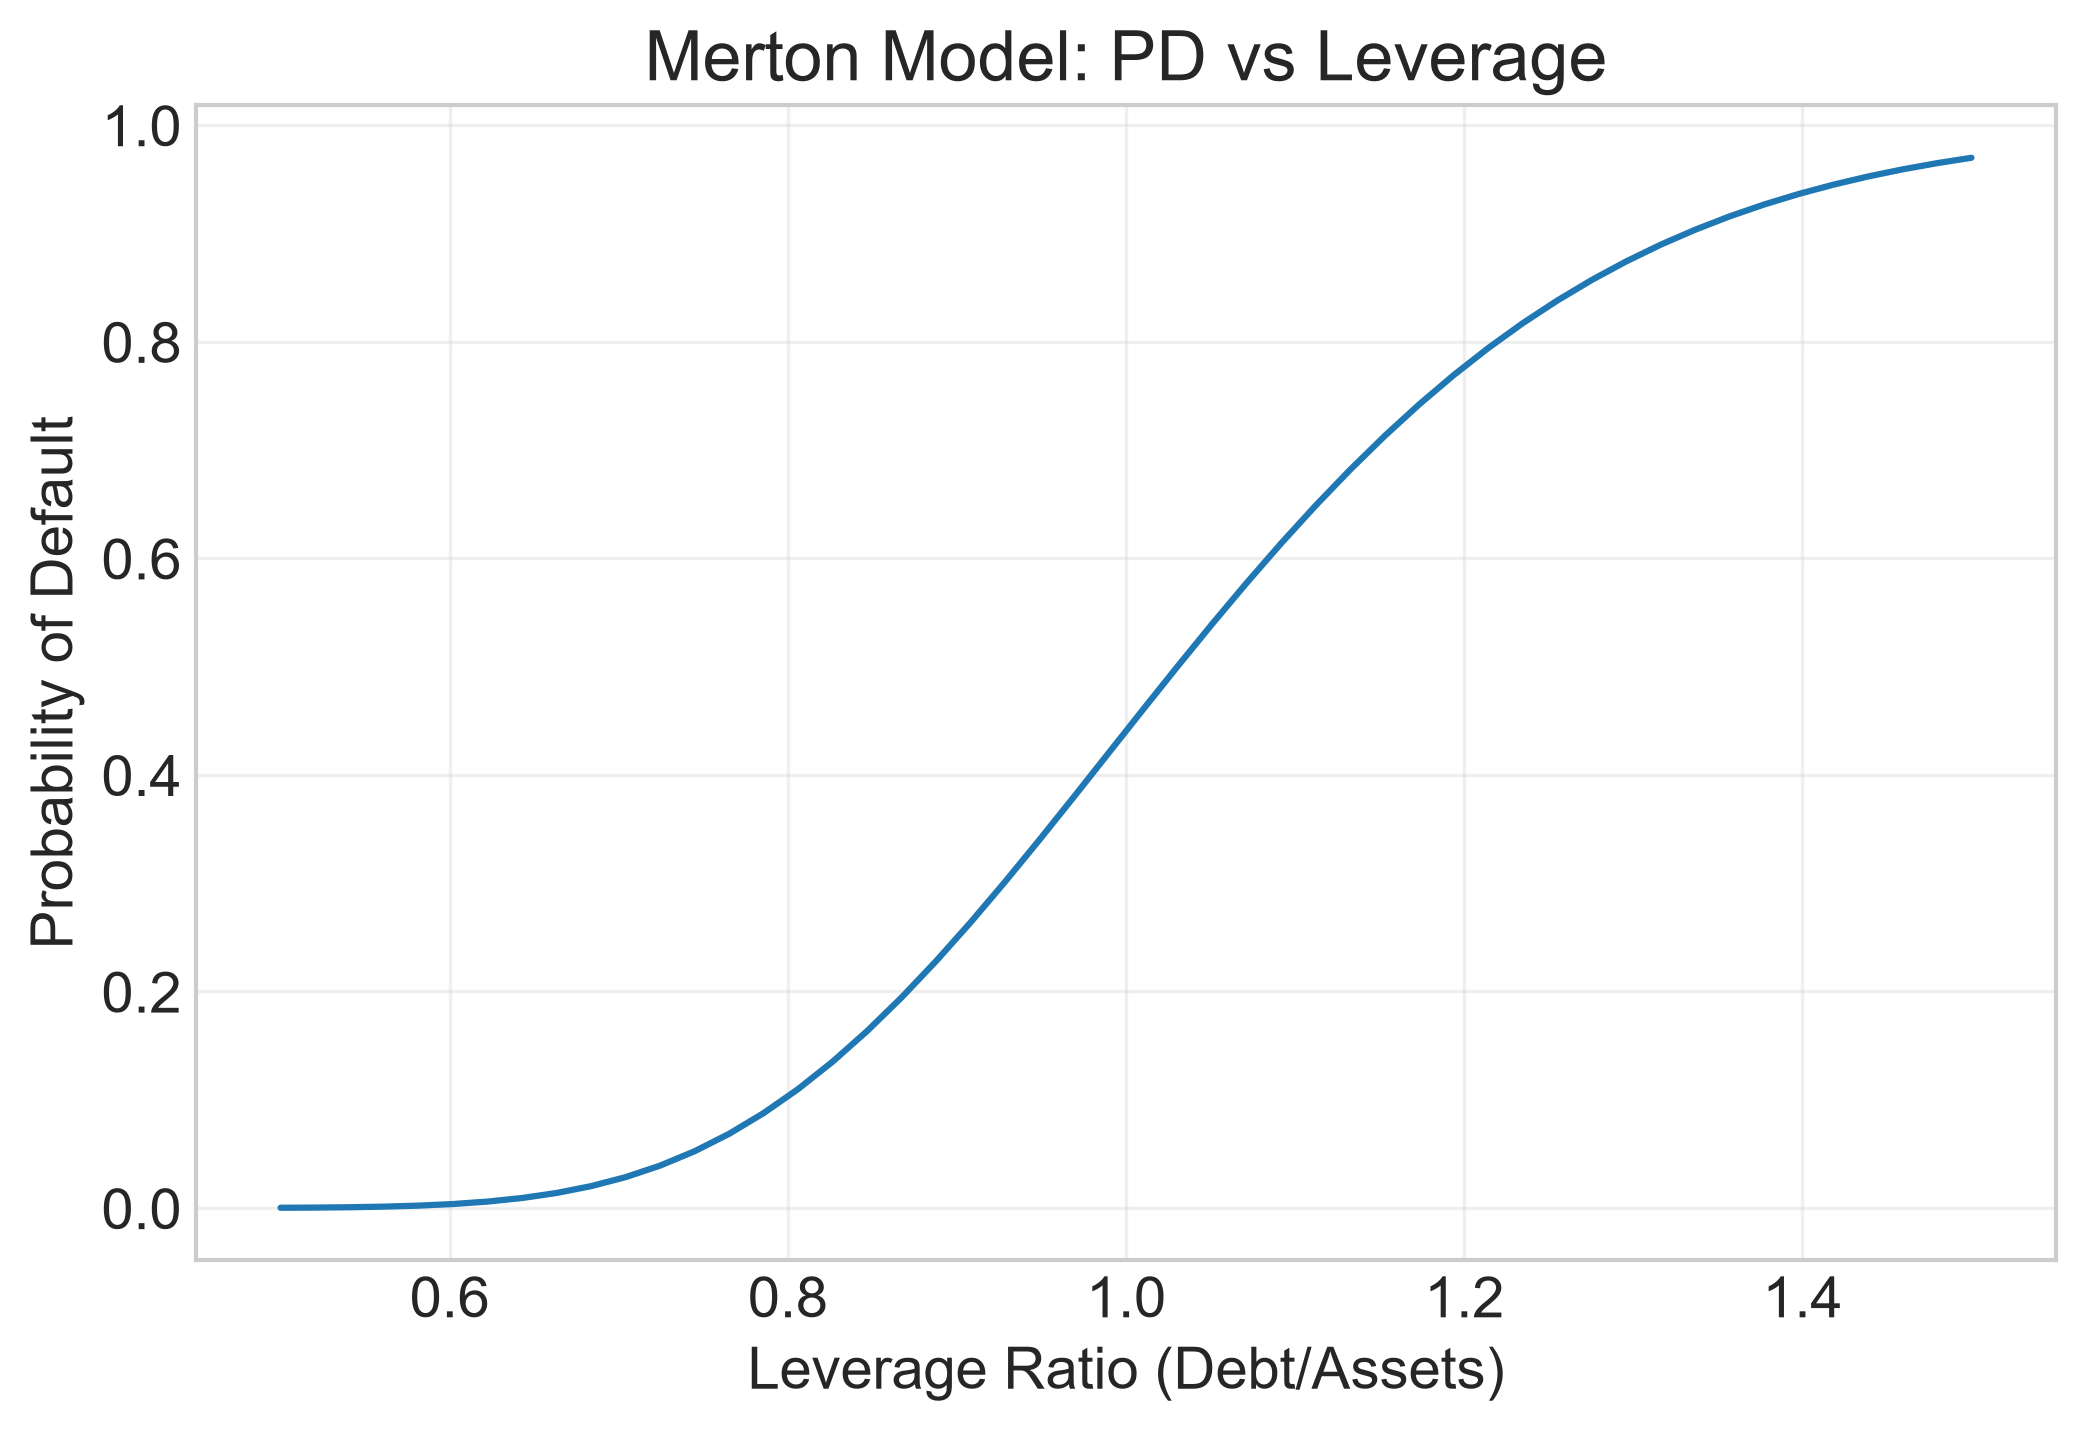

In [5]:
# --- Reuse the canonical Merton credit-metrics implementation ---

# Parameters
V_0 = 100      # Asset value
D = 80         # Debt face value
T = 1.0        # Maturity (years)
r = 0.05       # Risk-free rate
sigma_V = 0.2  # Asset volatility

metrics = merton_credit_metrics(V_0, D, T, r, sigma_V)
E = metrics["Equity"]
PD = metrics["PD"]
spread_bps = metrics["Spread"] * 10_000

print(f"Firm Asset Value: {V_0}")
print(f"Debt Face Value:  {D}")
print("-" * 30)
print(f"Equity Value:             {E:.4f}")
print(f"Probability of Default:   {PD:.4%}")
print(f"Credit Spread:            {spread_bps:.2f} bps")

# Visualizing PD vs Leverage
leverage_ratios = np.linspace(0.5, 1.5, 50)  # D/V
pds = []
for lev in leverage_ratios:
    D_i = V_0 * lev
    pds.append(merton_credit_metrics(V_0, D_i, T, r, sigma_V)["PD"])

plt.figure(figsize=(8, 5))
plt.plot(leverage_ratios, pds)
plt.xlabel("Leverage Ratio (Debt/Assets)")
plt.ylabel("Risk-Neutral Probability of Default")
plt.title("Merton Model: PD vs Leverage")
plt.grid(True, alpha=0.3)
plt.show()


---
## Summary

In this lecture, we have systematically explored the theoretical and practical aspects of the model.

**Key Takeaways:**
1.  **Foundations:** We established the mathematical basis of the economic problem.
2.  **Computation:** We implemented the solution using efficient algorithms.
3.  **Implications:** We analyzed the economic significance of the results.

**Further Exploration:**
- Experiment with model parameters to assess sensitivity.
- Extend the framework by relaxing simplifying assumptions.


## References & Further Reading

- Cochrane, J. H. (2005). *Asset Pricing* (rev. ed.). Princeton University Press.
- Campbell, J. Y., Lo, A. W. & MacKinlay, A. C. (1997). *The Econometrics of Financial Markets*. Princeton University Press.
- Shreve, S. E. (2004). *Stochastic Calculus for Finance II*. Springer.
